<a href="https://colab.research.google.com/github/pvlakshm/AIML/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from tensorflow.keras.datasets import mnist

# 1. Load and Prepare Data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Flatten 28x28 images to 784-element arrays and scale pixels to [0, 1]
x_train = x_train.reshape(60000, 784).T / 255.0
x_test = x_test.reshape(10000, 784).T / 255.0

# One-hot encode labels (e.g., '3' becomes [0,0,0,1,0,0,0,0,0,0])
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

y_train_encoded = one_hot(y_train)

# 2. Initialize Parameters
def init_params():
    W1 = np.random.rand(128, 784) - 0.5
    b1 = np.random.rand(128, 1) - 0.5
    W2 = np.random.rand(10, 128) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    exp = np.exp(Z - np.max(Z)) # Subtract max for numerical stability
    return exp / np.sum(exp, axis=0)

# 3. Training Functions
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    dZ2 = A2 - Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * (Z1 > 0) # Derivative of ReLU
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

# 4. The Training Loop
def train_model(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if i % 50 == 0:
            predictions = np.argmax(A2, axis=0)
            accuracy = np.sum(predictions == y_train) / y_train.size
            print(f"Iteration {i}: Accuracy {accuracy:.4f}")
    return W1, b1, W2, b2

# Execute Training
W1, b1, W2, b2 = train_model(x_train, y_train_encoded, 500, 0.1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iteration 0: Accuracy 0.1285
Iteration 50: Accuracy 0.3407
Iteration 100: Accuracy 0.4917
Iteration 150: Accuracy 0.5783
Iteration 200: Accuracy 0.6300
Iteration 250: Accuracy 0.6664
Iteration 300: Accuracy 0.6932
Iteration 350: Accuracy 0.7144
Iteration 400: Accuracy 0.7311
Iteration 450: Accuracy 0.7461


Prediction: [4]
Label: 4


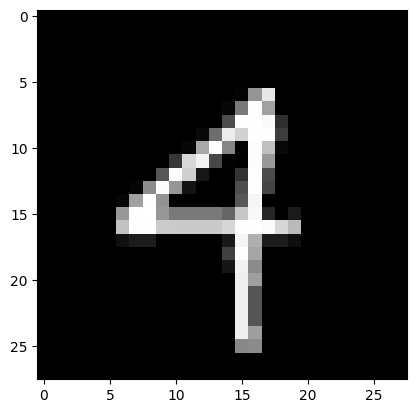

Prediction: [3]
Label: 3


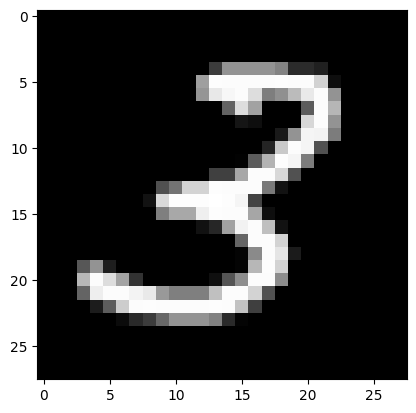

Prediction: [7]
Label: 8


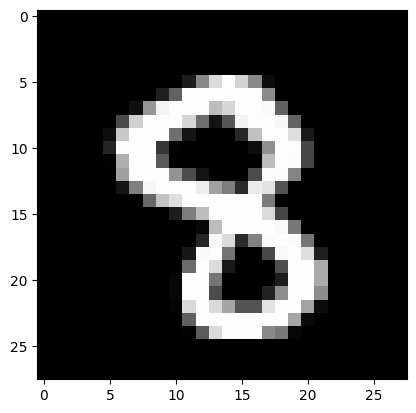

In [2]:
import matplotlib.pyplot as plt

def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = np.argmax(A2, axis=0)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = x_test[:, index, None]
    prediction = make_predictions(x_test[:, index, None], W1, b1, W2, b2)
    label = y_test[index]

    print(f"Prediction: {prediction}")
    print(f"Label: {label}")

    # Reshape the image back to 28x28 for display
    display_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(display_image, interpolation='nearest')
    plt.show()

# Test a few random examples
for i in range(3):
    random_idx = np.random.randint(0, 10000)
    test_prediction(random_idx, W1, b1, W2, b2)